# Sequential Convex Programming for Trajectory Generation

### Libraries

In [1]:
%load_ext autoreload
%autoreload 2

from jax import config
config.update("jax_enable_x64", True)

import os
import copy
import pickle
import warnings
import numpy as np
from cvxpygen import cpg
import matplotlib.pyplot as plt


from mpc import RUN
from scp import prox_convex
from cvx import parse_convex_problem
from disc import jit_int_mult_fcn, jit_cal_disc_fcn
from jitting import jit_ncvx_dt_fcn_grad, jit_ncvx_ct_fcn_grad, jit_ncvx_cvx_fcn_grad, jit_ncvx_smth_fcn_grad, jit_ncvx_comp_fcn_grad

from utils import profile_with_cprofile, make_anim

from model.di_always_stc.dynamics import dynamics
from model.di_always_stc.params import params_fcn, scale_params, unscale_prox_results
from model.di_always_stc.cost_cons import cvx_cost_fcn, cvx_cons_fcn, ncvx_dt_fcn, ncvx_ct_fcn, ncvx_cvx_fcn, ncvx_cvx_cp_fcn, ncvx_smth_fcn, ncvx_comp_fcn
from model.di_always_stc.plot import plot_always_demo_figure, save_individual_always_figures

warnings.filterwarnings("ignore")

### Parameters

In [2]:
K = 6 # Total number of nodes
t_f = 7.0 # Total simulation time [s] spd = 1

free_final_time = False
time_dil = False

params = params_fcn(t_f, K, free_final_time, time_dil)

params_sc = scale_params(copy.deepcopy(params))
params_sc = dynamics(copy.deepcopy(params_sc))

### Call functions

In [3]:
fcn_dict = {}

fcn_dict['cvx_cost_fcn'] = cvx_cost_fcn
fcn_dict['cvx_cons_fcn'] = cvx_cons_fcn

In [4]:
fcn_dict['cal_disc_jitted'] = jit_cal_disc_fcn(params_sc)
fcn_dict['int_mult_jitted'] = jit_int_mult_fcn(params_sc)

In [5]:
fcn_dict['ncvx_dt_fcn_jitted'], fcn_dict['ncvx_dt_fcn_grad_jitted'] = jit_ncvx_dt_fcn_grad(ncvx_dt_fcn, params_sc)
fcn_dict['ncvx_ct_fcn_jitted'], fcn_dict['ncvx_ct_fcn_grad_jitted'] = jit_ncvx_ct_fcn_grad(ncvx_ct_fcn, params_sc)

In [6]:
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------
fcn_dict['ncvx_cvx_fcn'] = ncvx_cvx_fcn
fcn_dict['ncvx_cvx_cp_fcn'] = ncvx_cvx_cp_fcn

fcn_dict['ncvx_cvx_fcn_jitted'], fcn_dict['ncvx_cvx_fcn_grad_jitted'] = jit_ncvx_cvx_fcn_grad(ncvx_cvx_fcn, params_sc)
fcn_dict['ncvx_smth_fcn_jitted'], fcn_dict['ncvx_smth_fcn_grad_jitted'] = jit_ncvx_smth_fcn_grad(ncvx_smth_fcn, params_sc)
fcn_dict['ncvx_comp_fcn_jitted'], fcn_dict['ncvx_comp_fcn_grad_jitted'] = jit_ncvx_comp_fcn_grad(ncvx_comp_fcn, params_sc)
# -------------------------------------------
# --------------- prox-convex ---------------
# -------------------------------------------

### Code generation

In [7]:
if not(params['use_generated_code']) or params['generate_code']:
    # Parse problem if you are not using the generated code
    cvx_prb = parse_convex_problem(params_sc, fcn_dict)

In [8]:
if params['generate_code']:
    # Generate code
    code_dir = "di_always_stc_solver"
    !rm -rf di_always_stc_solver/*
    os.makedirs(code_dir, exist_ok=True)  # <- This ensures the directory exists
    cpg.generate_code(cvx_prb, solver = params['convex_solver'], wrapper=True, code_dir=code_dir)

In [9]:
if params['use_generated_code']:
    # Use generated code
    with open('di_always_stc_solver/problem.pickle', 'rb') as f:
        cvx_prb = pickle.load(f)      

    from di_always_stc_solver.cpg_solver import cpg_solve
    cvx_prb.register_solve('CPG', cpg_solve)

### Prox-convex

In [10]:
prox_results_sc = prox_convex(  copy.deepcopy(params_sc), 
                                cvx_prb,
                                fcn_dict,
                                )

Ite          T-Ite        T-Disc       T-SubP       T-J_Np       dyn_cost     ctc_cost     obs_avd_1    obs_avd_5    none         ptr_cost     lcd          nlcd         lc           nlc          D-NL         D-L          Rho          W-TR         Note         Staus        
0            0            0            0            0            999999.99    0.0          0.0          0.0          0.0          0.0          0.0          999999.99    0.0          999999.99    0            0            0            1.0          Start        Start        
1            0.0419       0.0005       0.0018       0.0372       999999.99    0.0          0.0          0.0          0.0          90.6898      184.4867     999999.99    275.1765     999999.99    999999.99    999999.99    0.5131       1.0          First        1 (for description visit https://qoco-org.github.io/qoco/)
2            0.0051       0.0          0.0017       0.0016       388359.1317  19.8854      0.0          0.0          0.0          18.

In [11]:
print('Total iteration      time:', round(sum(prox_results_sc['T-Ite']), 4))
print('Total discretization time:', round(sum(prox_results_sc['T-Disc']), 4))
print('Total subproblem     time:', round(sum(prox_results_sc['T-SubP']), 4))
print('Total Jax to Numpy   time:', round(sum(prox_results_sc['T-J_Np']), 4))

print('\n')

tot_dsj = sum(prox_results_sc['T-Disc']) + sum(prox_results_sc['T-SubP']) + sum(prox_results_sc['T-J_Np'])
print('Total disc-subp-j_np time:', round(tot_dsj, 3))
print('Total others         time:', round(sum(prox_results_sc['T-Ite']) - tot_dsj, 3))

print('\n')

print('Flight time:', round(prox_results_sc['S_new'].sum(), 3))

Total iteration      time: 5.8349
Total discretization time: 0.0313
Total subproblem     time: 1.4992
Total Jax to Numpy   time: 1.8294


Total disc-subp-j_np time: 3.36
Total others         time: 2.475


Flight time: 0.0


### Dump results

In [12]:
# with open('prox_results_sc.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(prox_results_sc))

In [13]:
# with open('prox_results_sc.pickle', 'rb') as f:
#     prox_results_sc = pickle.load(f)      

In [14]:
# with open('results.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(results))
    
# with open('params.pickle', 'wb') as out_f:
#     out_f.write(pickle.dumps(params))

### Simulate

In [15]:
prox_results = unscale_prox_results(copy.deepcopy(prox_results_sc), params)

params = dynamics(copy.deepcopy(params))

results = RUN(copy.deepcopy(prox_results), 
                 copy.deepcopy(params))

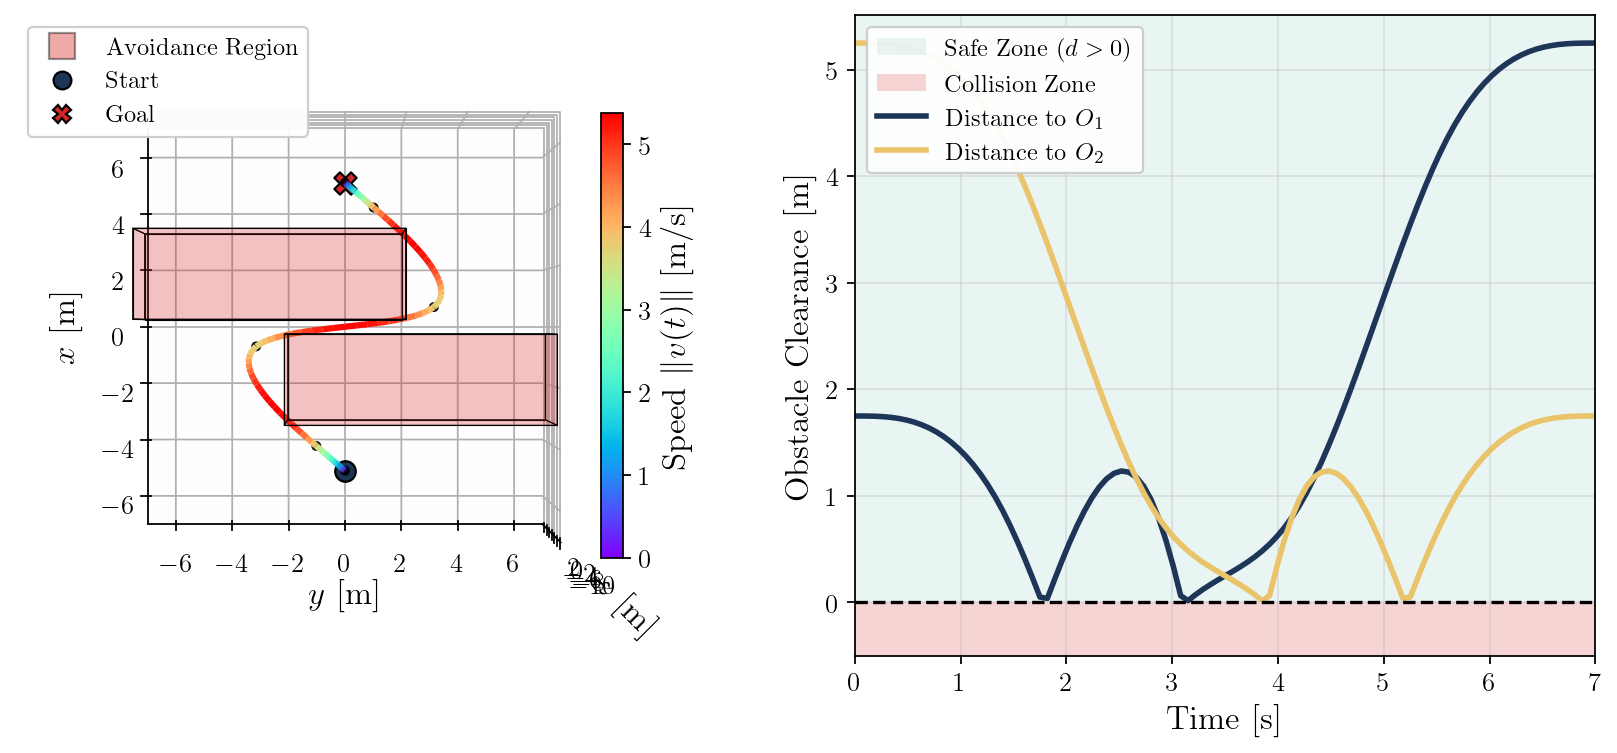

In [ ]:
plot_always_demo_figure(results, params, savepath='Figures/always_stc_aug_all')

In [ ]:
save_individual_always_figures(results, params, save_dir='Figures/always_stc_aug')

Saved individual 'Always' figures to: Figures/always_stc
